# LANG Dataset for European Language Recognition
- The encoding in this part is different as it uses ngram encoding where it is a 2-level series bundling and binding process.

In [1]:
# Parameters
import os
import sys
import numpy as np

# Path directories
curr_dir = os.getcwd()
lib_path = curr_dir + "/../../lib"
extract_path = curr_dir + "/../../extract_data"
data_path = curr_dir + "/../../data"
training_path = data_path + "/training_texts"
testing_path = data_path + "/testing_compressed_texts"

# Appending other paths for libraries
sys.path.append(lib_path)
sys.path.append(extract_path)

import vsa
import figs
from extract_data_util import download_and_extract, read_data, split_data

## Data Extraction
- Data extraction is different as we re-use the one in **Hypercorex** project.
- Original dataset comes from this [git repository](https://github.com/abbas-rahimi/HDC-Language-Recognition/tree/master).
- The compressed one is from the [hypercorex repository](https://github.com/KULeuven-MICAS/hypercorex/releases/tag/ds_hdc_lang_recog_v.0.0.1).

In [2]:
# Downloading of data
url_testing = "https://github.com/KULeuven-MICAS/hypercorex/releases/download/ds_hdc_lang_recog_v.0.0.1/lang_recog_testing.tar.gz"
url_training = "https://github.com/KULeuven-MICAS/hypercorex/releases/download/ds_hdc_lang_recog_v.0.0.1/lang_recog_training.tar.gz"

download_and_extract(
    url=url_training,
    out_dir=data_path,
    delete_archive=True,
)

download_and_extract(
    url=url_testing,
    out_dir=data_path,
    delete_archive=True,
)

# Custom function just to read the data
def extract_lang_dataset(read_file):
    # Extract file to be tested
    text_lines = []
    with open(read_file, "r") as rf:
        for line in rf:
            line = line.strip()
            text_lines.append(line)
    rf.close()
    return text_lines

# Dataset characteristics
class_list = {
    0: "bul",
    1: "ces",
    2: "dan",
    3: "nld",
    4: "deu",
    5: "eng",
    6: "est",
    7: "fin",
    8: "fra",
    9: "ell",
    10: "hun",
    11: "ita",
    12: "lav",
    13: "lit",
    14: "pol",
    15: "por",
    16: "ron",
    17: "slk",
    18: "slv",
    19: "spa",
    20: "swe",
}

char_map = {
    "a": 0,
    "b": 1,
    "c": 2,
    "d": 3,
    "e": 4,
    "f": 5,
    "g": 6,
    "h": 7,
    "i": 8,
    "j": 9,
    "k": 10,
    "l": 11,
    "m": 12,
    "n": 13,
    "o": 14,
    "p": 15,
    "q": 16,
    "r": 17,
    "s": 18,
    "t": 19,
    "u": 20,
    "v": 21,
    "w": 22,
    "x": 23,
    "y": 24,
    "z": 25,
    "\x1f": 26,  # End of text character
    " ": 26,  # Space character
}

# Loading data
train_data = dict()
for lang in class_list:
        read_file = training_path + "/" + class_list[lang] + ".txt"
        train_data[lang] = extract_lang_dataset(read_file)


test_data = dict()
for lang in class_list:
    read_file = testing_path + "/" + class_list[lang] + "_test.txt"
    test_data[lang] = extract_lang_dataset(read_file)


# Splitting training set with train and valid
# For the sake of faster training, getting much less samples for training and validation
compress_train = 0.90
_, compress_train_data = split_data(train_data, class_list, split_percent=compress_train)
train_valid_split = 0.75
train_data, valid_data = split_data(compress_train_data, class_list, split_percent=train_valid_split)

# Some post-process to convert characters into numbers
for lang in class_list:
    train_data[lang] = [[char_map[char] for char in item] for item in train_data[lang]]
    valid_data[lang] = [[char_map[char] for char in item] for item in valid_data[lang]]
    test_data[lang] = [[char_map[char] for char in item] for item in test_data[lang]]

Extracting...
Deleted archive: lang_recog_training.tar.gz
Extraction complete!
Extracting...
Deleted archive: lang_recog_testing.tar.gz
Extraction complete!


Splitting data: 100%|██████████| 21/21 [00:00<00:00, 1971.01it/s]


## VSA Model
- VSA model uses ngram encodinf which consists of a sliding window encoding. It is better represented through an expanded equation form.

$$ \mathcal{hv}_{\textrm{enc}} = \left(\rho(\mathcal{hv}_{\textrm{char}}[0]) \otimes \rho^2 (\mathcal{hv}_{\textrm{char}}[1]) \otimes \rho^3 (\mathcal{hv}_{\textrm{char}}[2]) \right) \\ + \left(\rho(\mathcal{hv}_{\textrm{char}}[1]) \otimes \rho^2 (\mathcal{hv}_{\textrm{char}}[2]) \otimes \rho^3 (\mathcal{hv}_{\textrm{char}}[3]) \right) + \\ ... + \left(\rho(\mathcal{hv}_{\textrm{char}}[N_{\textrm{seq}}-3]) \otimes \rho^2 (\mathcal{hv}_{\textrm{char}}[N_{\textrm{seq}}-2]) \otimes \rho^3 (\mathcal{hv}_{\textrm{char}}[N_{\textrm{seq}-1}]) \right)$$

- The above equation shows trigram (`ngram=3`).

In [3]:
class dnaVSA(vsa.ModelVSA):
    def encode(self, item_data):
        # Set ngram parameter
        ngram = 3
        # Feature length
        item_len = len(item_data)
        # Set the correct initialization
        encoded_vec = np.zeros(self.hv_size)

        # Iterate through different item
        for i in range(item_len-ngram):
            ngram_vec = np.ones(self.hv_size)
            for j in range(ngram):
                # Create ngram vector set
                ngram_vec *= vsa.hv_perm(self.ortho_im[item_data[i+j]], j)
            encoded_vec += ngram_vec
        # Threshold for binarization
        threshold = (item_len-ngram) // 2
        # Binarization
        if self.binarize_encode:
            encoded_vec = vsa.binarize_hv(encoded_vec, threshold, self.hv_type)
        return encoded_vec

# Training, Retraining, and Testing
- This time we add a switch to collect the accuracies in a list varying the HV dimensions

In [4]:
# Parameters
hv_dim_set = [512, 1024, 2048, 4096, 8192]
hv_dim_set_len = len(hv_dim_set)
accuracy_list = np.zeros(hv_dim_set_len)

In [8]:
for hv_dim in hv_dim_set:
    print(f"Running HV Dimension: {hv_dim}")
    # Create the VSA model with target parameters
    lang_model = dnaVSA(
        hv_size = hv_dim,
        class_list = class_list,
    )

    # CHANGE ME FOR EXPERIMENTATION:
    # Add the following to binarize the encoded value
    lang_model.binarize_encode = True
    # Add the following to binarize the AM
    lang_model.binarize_am = True

    # For debug parameters only
    lang_model.tqdm_train_mode = False
    lang_model.tqdm_retrain_mode = False
    lang_model.tqdm_test_mode = False

    # Train the model
    lang_model.train_model(train_data)

    # Retraining the model
    lang_model.retrain_model(valid_data)

    # Test the model
    lang_model.test_model(test_data)

    # Save accuracy
    accuracy_list[hv_dim_set.index(hv_dim)] = lang_model.model_accuracy

for i in range(len(accuracy_list)):
    accuracy_list[i] = accuracy_list[i]*100

accuracy_list

Running HV Dimension: 512


Training complete!
Retraining complete!
Testing complete!
Running HV Dimension: 1024
Training complete!
Retraining complete!
Testing complete!
Running HV Dimension: 2048
Training complete!
Retraining complete!
Testing complete!
Running HV Dimension: 4096
Training complete!
Retraining complete!
Testing complete!
Running HV Dimension: 8192
Training complete!
Retraining complete!
Testing complete!


array([84.17941751, 90.84322418, 93.93202727, 95.7957958 , 96.63472997])

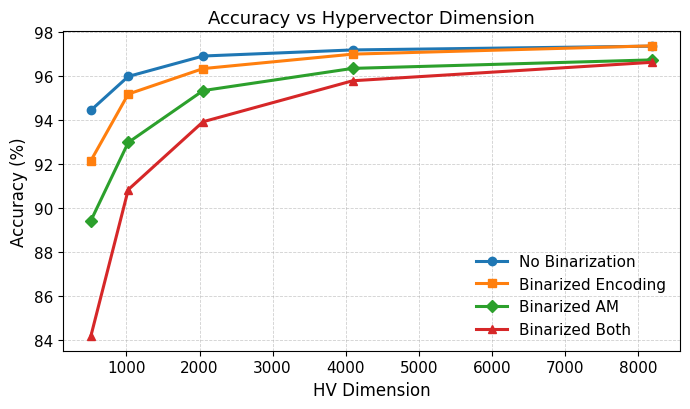

In [9]:
acc = [
    [94.45159445, 95.99122932, 96.92073025, 97.1971972 , 97.36879737],
    [92.15882549, 95.19042852, 96.34872968, 97.00653034, 97.38309738],
    [89.42752276, 92.98822632, 95.34772868, 96.35826302, 96.74436341],
    [84.17941751, 90.84322418, 93.93202727, 95.7957958 , 96.63472997],
    
]

hv_dim = [512, 1024, 2048, 4096, 8192]

legend = ['No Binarization', 'Binarized Encoding', 'Binarized AM', 'Binarized Both']
x_label = 'HV Dimension'
y_label = 'Accuracy (%)'
title = 'Accuracy vs Hypervector Dimension'

figs.multiLinePlot(
    x_data=hv_dim,
    y_data_list=acc,
    legend_list=legend,
    x_label=x_label,
    y_label=y_label,
    title=title,
).plot_fig()

In [10]:
lang_model.print_model_stats()


-----------------
Model Statistics:
-----------------
HV Size: 8192
HV Type: bipolar
Number of Orthogonal IMs: 1024
Number of Continuous IMs: 21
Number of Classes: 21
Binarize Encode: True
Binarize AM: True
Class 0 Accuracy: 97.90%
Class 1 Accuracy: 91.39%
Class 2 Accuracy: 96.20%
Class 3 Accuracy: 97.90%
Class 4 Accuracy: 98.30%
Class 5 Accuracy: 98.30%
Class 6 Accuracy: 97.50%
Class 7 Accuracy: 98.30%
Class 8 Accuracy: 97.10%
Class 9 Accuracy: 98.00%
Class 10 Accuracy: 98.50%
Class 11 Accuracy: 98.80%
Class 12 Accuracy: 96.50%
Class 13 Accuracy: 97.00%
Class 14 Accuracy: 98.00%
Class 15 Accuracy: 98.40%
Class 16 Accuracy: 98.10%
Class 17 Accuracy: 85.79%
Class 18 Accuracy: 96.10%
Class 19 Accuracy: 95.20%
Class 20 Accuracy: 96.10%
Overall Accuracy: 96.63%


## Some Conclusions
- The output is also clear! Non-binarized gets best accuracies.
- Binarizing encoding is useful for higher dimensions.
- Non-binarized for lower.
- AM should not be binarized at all!